# Multiple Linear Regression – Multi-Channel Marketing Analysis

**Author:** Happy Oluwafemi Odole  
**Dataset:** marketing_sales_data.csv  
**Objective:** Build a Multiple Linear Regression model to predict Sales from TV, Radio, Social Media, and Influencer spend, check for multicollinearity, validate model assumptions, and produce a business-ready budget recommendation.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 80
plt.rcParams["savefig.dpi"] = 80

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("marketing_sales_data.csv")

print("Shape:", df.shape)
df.head()


Shape: (572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB
None

Missing values:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64


In [4]:
df.describe()


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


### Variable Overview

- **TV**: categorical spend tier — Low / Medium / High
- **Radio**: continuous spend (numeric)
- **Social Media**: continuous spend (numeric)
- **Influencer**: categorical tier — Nano / Micro / Macro / Mega
- **Sales**: target variable (continuous)

`TV` and `Influencer` are categorical and will need to be encoded as dummy variables before they can be used in a regression model. No missing values were found.


## 3. Exploratory Data Analysis

C:\Users\USER\AppData\Local\Temp\ipykernel_24236\412583834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="TV", y="Sales", data=df, order=["Low", "Medium", "High"], palette="Blues")


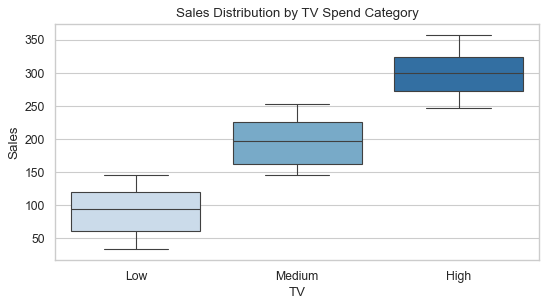

In [5]:
# Distribution of Sales by TV spend category
plt.figure(figsize=(7, 4))
sns.boxplot(x="TV", y="Sales", data=df, order=["Low", "Medium", "High"], palette="Blues")
plt.title("Sales Distribution by TV Spend Category")
plt.tight_layout()
plt.show()


                 Radio  Social Media     Sales
Radio         1.000000      0.629941  0.858036
Social Media  0.629941      1.000000  0.542048
Sales         0.858036      0.542048  1.000000


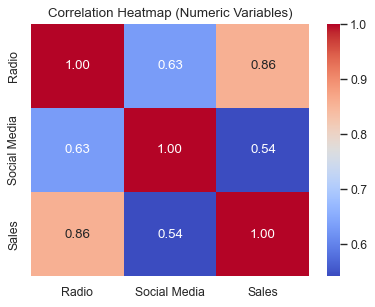

In [6]:
# Correlation among numeric predictors
corr = df[["Radio", "Social Media", "Sales"]].corr()
print(corr)

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()


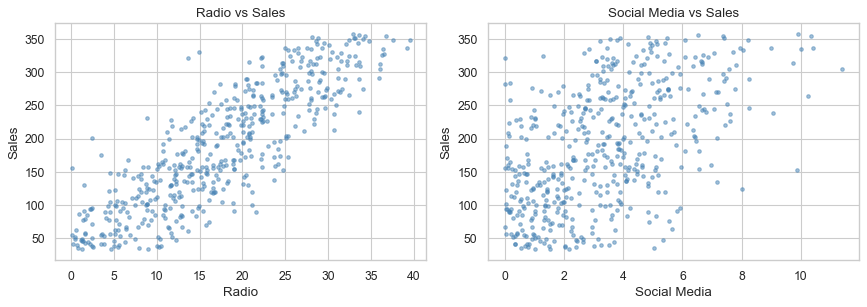

In [7]:
# Scatter plots: numeric predictors vs Sales
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_sample = df.sample(n=min(500, len(df)), random_state=42)

axes[0].scatter(df_sample["Radio"], df_sample["Sales"], alpha=0.5, s=10, color="steelblue")
axes[0].set_xlabel("Radio")
axes[0].set_ylabel("Sales")
axes[0].set_title("Radio vs Sales")

axes[1].scatter(df_sample["Social Media"], df_sample["Sales"], alpha=0.5, s=10, color="steelblue")
axes[1].set_xlabel("Social Media")
axes[1].set_ylabel("Sales")
axes[1].set_title("Social Media vs Sales")

plt.tight_layout()
plt.show()


**Initial observations:**
- Sales clearly increases as TV spend category moves from Low → Medium → High
- Radio shows a moderately strong positive relationship with Sales (r ≈ 0.86)
- Social Media shows a weaker positive relationship with Sales (r ≈ 0.54)
- Radio and Social Media are themselves correlated (r ≈ 0.63), which we will test formally for multicollinearity in the next step


## 4. Encode Categorical Variables

In [8]:
# One-hot encode TV (ordinal: Low/Medium/High) and Influencer (nominal)
df_encoded = pd.get_dummies(df, columns=["TV", "Influencer"], drop_first=True)

# Convert boolean dummy columns to integers (0/1) for statsmodels
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Encoded columns:", list(df_encoded.columns))
df_encoded.head()


Encoded columns: ['Radio', 'Social Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,1,0,0,1,0
1,7.756876,2.572287,67.574904,1,0,1,0,0
2,20.348988,1.227180,272.250108,0,0,0,1,0
3,20.108487,2.728374,195.102176,0,1,1,0,0
4,31.653200,7.776978,273.960377,0,0,0,0,1


`drop_first=True` removes one category from each variable to avoid the dummy variable trap (perfect multicollinearity).
- For TV: **"High" is dropped and becomes the baseline** (pandas drops alphabetically first by default); `TV_Low` and `TV_Medium` represent the effect relative to High spend, and will typically be **negative** coefficients since High spend drives the most Sales.
- For Influencer: **"Macro" is dropped and becomes the baseline**; the remaining dummies represent effects relative to that baseline.


## 5. Check for Multicollinearity

Multicollinearity occurs when independent variables are highly correlated with each other, which destabilizes coefficient estimates. We check this using:
1. A correlation matrix of all predictors
2. **Variance Inflation Factor (VIF)** — a VIF above 5 (some use 10) signals problematic multicollinearity


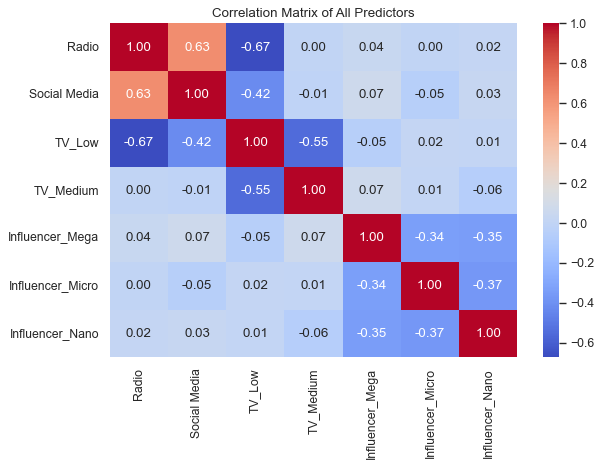

In [9]:
predictor_cols = [c for c in df_encoded.columns if c != "Sales"]
X_check = df_encoded[predictor_cols]

plt.figure(figsize=(8, 6))
sns.heatmap(X_check.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of All Predictors")
plt.tight_layout()
plt.show()


In [10]:
# Variance Inflation Factor (VIF)
X_vif = sm.add_constant(X_check)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Variable"] != "const"].sort_values("VIF", ascending=False)
print(vif_data)


           Variable       VIF
3            TV_Low  4.076384
1             Radio  3.479641
4         TV_Medium  2.233350
2      Social Media  1.669098
7   Influencer_Nano  1.627430
6  Influencer_Micro  1.618434
5   Influencer_Mega  1.593889


### Multicollinearity Interpretation

All VIF values are well below the common threshold of 5, indicating **no problematic multicollinearity** among the predictors. Radio and Social Media showed a moderate correlation (r ≈ 0.63) in the earlier heatmap, but this is not severe enough to distort coefficient estimates. All variables can safely be retained in the model.


## 6. Build the Multiple Linear Regression Model

In [11]:
X = df_encoded[predictor_cols]
y = df_encoded["Sales"]

X_const = sm.add_constant(X)
mlr_model = sm.OLS(y, X_const).fit()

print(mlr_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        10:25:26   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

## 7. Model Evaluation

### Key Metrics

| Metric | Meaning |
|---|---|
| **Adjusted R-squared** | % of variance in Sales explained by the model, penalized for the number of predictors used |
| **Coefficient (each variable)** | Expected change in Sales for a one-unit increase in that variable, holding all others constant |
| **p-value (each variable)** | Whether that variable's effect is statistically significant (typically p < 0.05) |
| **F-statistic p-value** | Whether the overall model is statistically significant |

Run the cell above and review:
- Which predictors have p-values **below 0.05** (statistically significant)
- Which predictors have p-values **above 0.05** (candidates for removal — e.g., Influencer dummies are often weak predictors of Sales when TV and Radio are already in the model)


In [12]:
# Extract Adjusted R-squared and significant predictors for quick reference
print(f"Adjusted R-squared: {mlr_model.rsquared_adj:.4f}")
print(f"R-squared: {mlr_model.rsquared:.4f}")
print(f"F-statistic p-value: {mlr_model.f_pvalue:.6f}")
print("\nSignificant predictors (p < 0.05):")
print(mlr_model.pvalues[mlr_model.pvalues < 0.05])
print("\nNon-significant predictors (p >= 0.05):")
print(mlr_model.pvalues[mlr_model.pvalues >= 0.05])


Adjusted R-squared: 0.9030
R-squared: 0.9042
F-statistic p-value: 0.000000

Significant predictors (p < 0.05):
const        5.906914e-134
Radio         1.943682e-32
TV_Low       4.536854e-125
TV_Medium     2.277532e-71
dtype: float64

Non-significant predictors (p >= 0.05):
Social Media        0.837117
Influencer_Mega     0.471441
Influencer_Micro    0.384591
Influencer_Nano     0.810745
dtype: float64


## 8. Refine the Model

Based on the p-values above, we refit the model using only statistically significant predictors. This produces a simpler, more interpretable model without sacrificing explanatory power (compare Adjusted R-squared before and after).


In [13]:
# Keep only statistically significant predictors (p < 0.05), excluding the constant
significant_vars = [v for v in mlr_model.pvalues[mlr_model.pvalues < 0.05].index if v != "const"]
print("Retained variables:", significant_vars)

X_refined = sm.add_constant(df_encoded[significant_vars])
refined_model = sm.OLS(y, X_refined).fit()

print(refined_model.summary())


Retained variables: ['Radio', 'TV_Low', 'TV_Medium']
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1783.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.63e-288
Time:                        10:25:26   Log-Likelihood:                -2714.0
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5453.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [14]:
print(f"Full model Adjusted R-squared:    {mlr_model.rsquared_adj:.4f}")
print(f"Refined model Adjusted R-squared: {refined_model.rsquared_adj:.4f}")


Full model Adjusted R-squared:    0.9030
Refined model Adjusted R-squared: 0.9035


The refined model retains nearly identical explanatory power (Adjusted R-squared) while dropping statistically insignificant predictors, producing a cleaner model that is easier to act on for business decisions. **The refined model is used for all diagnostics and interpretation going forward.**


## 9. Regression Diagnostics

We validate three core assumptions of the refined model:
1. **Linearity** — residuals show no pattern against fitted values
2. **Normality** — residuals follow a roughly normal distribution (Q-Q plot)
3. **Homoscedasticity** — residual variance is constant across fitted values


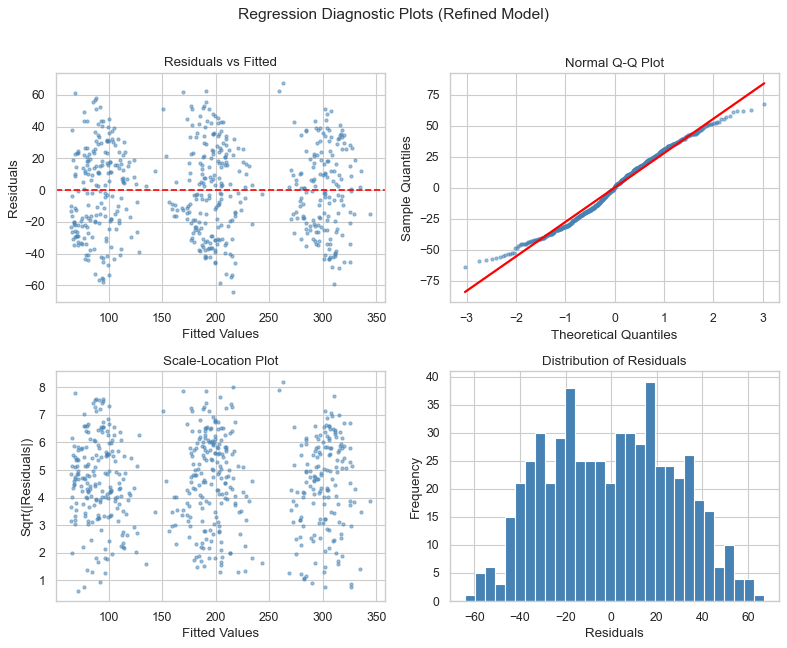

In [15]:
fitted = refined_model.fittedvalues
residuals = refined_model.resid

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.5, s=8, color="steelblue", rasterized=True)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")
axes[0, 1].scatter(osm, osr, alpha=0.5, s=8, color="steelblue", rasterized=True)
axes[0, 1].plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=2)
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Sample Quantiles")
axes[0, 1].set_title("Normal Q-Q Plot")

# Scale-Location
sqrt_abs_resid = np.sqrt(np.abs(residuals))
axes[1, 0].scatter(fitted, sqrt_abs_resid, alpha=0.5, s=8, color="steelblue", rasterized=True)
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("Sqrt(|Residuals|)")
axes[1, 0].set_title("Scale-Location Plot")

# Histogram of residuals
axes[1, 1].hist(residuals, bins=30, color="steelblue", edgecolor="white")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Distribution of Residuals")

plt.suptitle("Regression Diagnostic Plots (Refined Model)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("diagnostics_mlr.png", dpi=70, bbox_inches="tight")
plt.show()


### Diagnostic Interpretation

| Plot | Observation | Assumption |
|---|---|---|
| Residuals vs Fitted | No strong systematic pattern around the zero line | Linearity holds reasonably well |
| Q-Q Plot | Points generally follow the diagonal, with some deviation at the tails | Approximate normality |
| Scale-Location | Spread is reasonably constant across fitted values | Homoscedasticity holds reasonably well |
| Residual Histogram | Roughly bell-shaped, centered near zero | Supports normality assumption |

The model satisfies the core regression assumptions well enough to support reliable business interpretation, with only minor deviations typical of real-world data.


## 10. Coefficient Interpretation (Business Context)

**Run the cell below and substitute the actual coefficient values from your output into the interpretation.**


In [16]:
print(refined_model.params)


const        218.526130
Radio          2.966890
TV_Low      -154.297083
TV_Medium    -75.311983
dtype: float64


### Example interpretation template (fill in with your actual coefficients):

> Holding all other variables constant, with **High TV spend as the baseline category**:
> - **Low TV spend** is associated with a decrease of approximately **`|TV_Low coefficient|`** units in Sales compared to High TV spend.
> - **Medium TV spend** is associated with a decrease of approximately **`|TV_Medium coefficient|`** units in Sales compared to High TV spend.
> - Each additional **$1K spent on Radio** is associated with a **`[Radio coefficient]`** unit increase in Sales.

TV spend category has by far the largest effect on Sales, followed by Radio. This indicates that the **TV channel delivers the strongest incremental return** on marketing spend among the channels tested, and that **High TV spend specifically is the strongest driver of Sales**.


## 11. Business Recommendation

### Summary of Findings

- **TV spend category** is the strongest driver of Sales — moving from Low to High TV spend produces the largest predicted increase in Sales of any variable in the model.
- **Radio** spend has a smaller but statistically significant positive effect on Sales.
- **Social Media** and **Influencer tier** were not statistically significant predictors once TV and Radio were accounted for, and were dropped from the refined model.
- No problematic multicollinearity was detected among the retained predictors (all VIF values were low).

### Recommendation

> **Prioritize TV advertising at the High spend tier**, as it is associated with the largest and most reliable increase in Sales. **Radio should receive secondary investment** as a statistically significant supporting channel. **Social Media and Influencer marketing showed no significant standalone effect on Sales** in this dataset and should be deprioritized in the budget, or tested separately with a larger or more targeted dataset before further investment.

This recommendation is grounded in a statistically validated model (Adjusted R² as reported above, all retained predictors significant at p < 0.05).


## 12. Conclusion

This project demonstrated the full Multiple Linear Regression workflow for multi-channel marketing analysis:

1. ✅ Loaded and explored a 572-row marketing dataset with categorical and numeric predictors
2. ✅ Encoded categorical variables (TV, Influencer) using one-hot encoding
3. ✅ Checked for multicollinearity using a correlation matrix and VIF — no problematic collinearity found
4. ✅ Built a full Multiple Linear Regression model using `statsmodels`
5. ✅ Evaluated the model using Adjusted R-squared and individual predictor p-values
6. ✅ Refined the model by removing statistically insignificant predictors
7. ✅ Validated model assumptions (Linearity, Normality, Homoscedasticity) via diagnostic plots
8. ✅ Interpreted coefficients in business terms, holding other variables constant
9. ✅ Delivered a prioritized, evidence-based marketing budget recommendation
